<a href="https://colab.research.google.com/github/nailasalmayusroini/Deep-Learning-Assignment/blob/main/Deep_Learning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment
Name: Naila Salma Yusroini

NIM: 24/536726/PA/22766

Class: CSB

In [3]:
from google.colab import files
uploaded = files.upload()

Saving PMM-TemplateSLP Assignment.xlsx - Training_Data.csv to PMM-TemplateSLP Assignment.xlsx - Training_Data (1).csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving PMM-TemplateSLP Assignment.xlsx - Validation_Data.csv to PMM-TemplateSLP Assignment.xlsx - Validation_Data (1).csv


=== TRAINING SUMMARY ===
Epoch 1: Loss = 0.449889  Accuracy = 0.5250
Epoch 2: Loss = 0.037452  Accuracy = 0.9500
Epoch 3: Loss = 0.024372  Accuracy = 0.9750
Epoch 4: Loss = 0.017357  Accuracy = 0.9750
Epoch 5: Loss = 0.012740  Accuracy = 0.9875

=== VALIDATION SUMMARY ===
Epoch 1: Loss = 0.328951  Accuracy = 0.5000
Epoch 2: Loss = 0.247289  Accuracy = 0.5000
Epoch 3: Loss = 0.175892  Accuracy = 0.5000
Epoch 4: Loss = 0.119381  Accuracy = 0.8500
Epoch 5: Loss = 0.081581  Accuracy = 1.0000


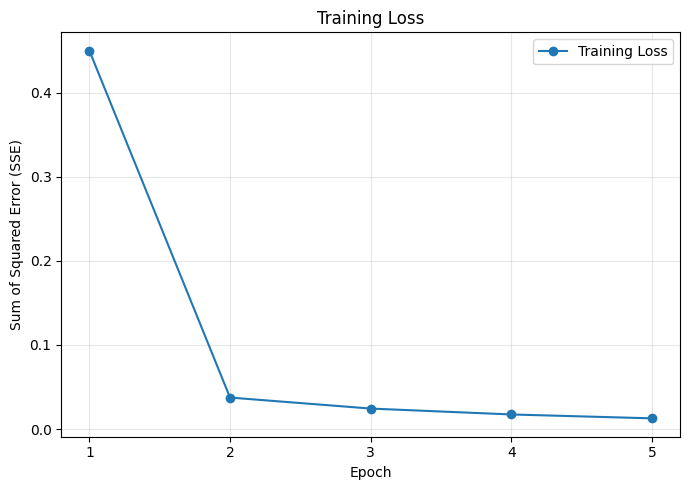

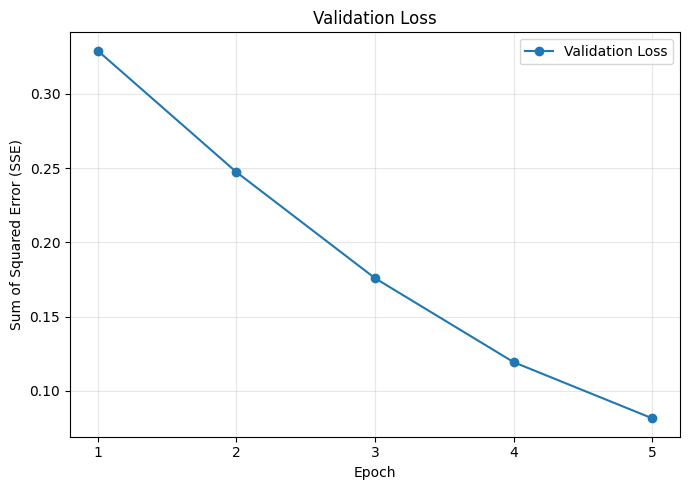

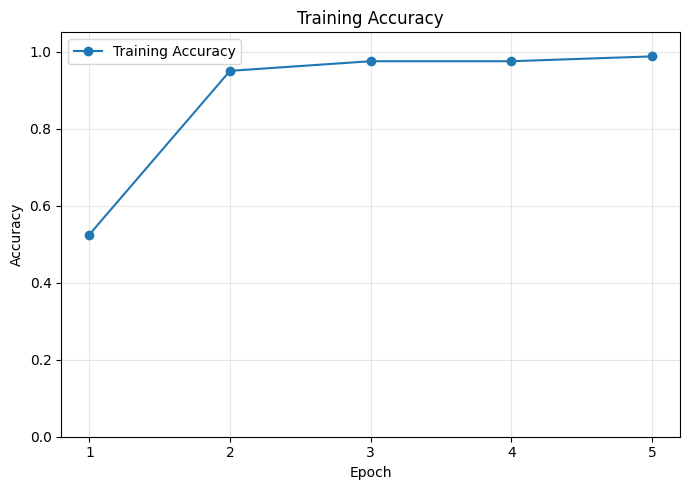

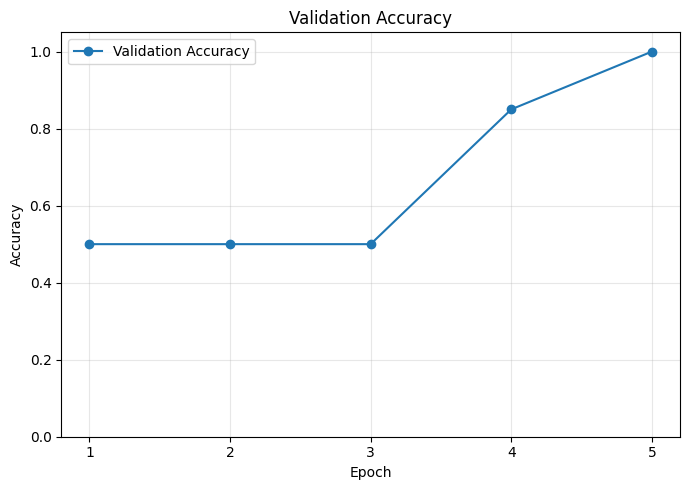

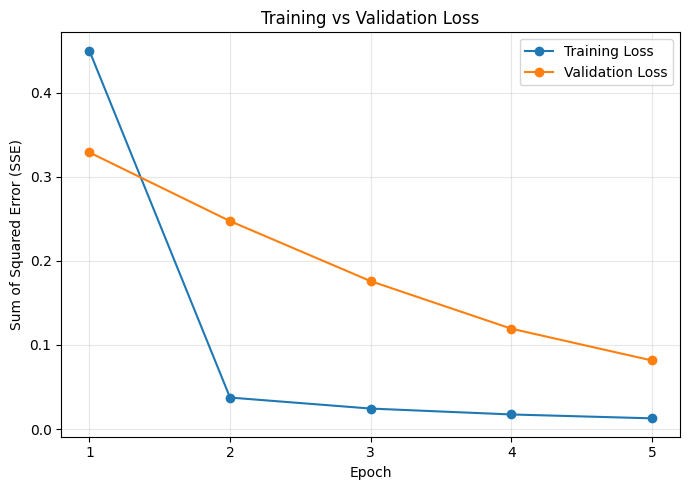

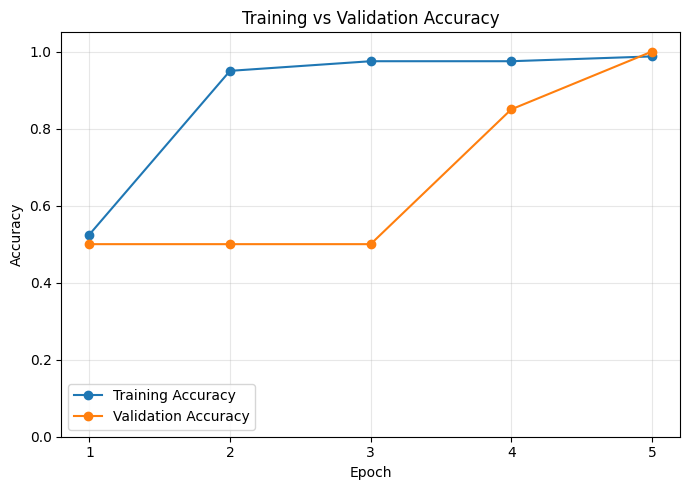

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA FROM THE UPLOADED CSVs
train_df = pd.read_csv("PMM-TemplateSLP Assignment.xlsx - Training_Data.csv")
val_df   = pd.read_csv("PMM-TemplateSLP Assignment.xlsx - Validation_Data.csv")

X_train = train_df[["X1", "X2", "X3", "X4"]].to_numpy()
y_train = train_df["TARGET"].to_numpy()

X_val = val_df[["X1", "X2", "X3", "X4"]].to_numpy()
y_val = val_df["TARGET"].to_numpy()

LEARNING_RATE = 0.1
N_EPOCHS = 5
INITIAL_WEIGHT = 0.5   # matches the sheet's starting bias/teta values


# 2. MATH FORMULAS

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def train_slp(X, y, lr=LEARNING_RATE, epochs=N_EPOCHS):
    """
    Online (per-sample) gradient descent -- weights update after EVERY row,
    matching the spreadsheet exactly:
        dbias = 2 * error * g(z) * (1 - g(z))
        weight_new = weight_old - lr * dbias  (dteta_i = dbias * x_i)
    """
    n_features = X.shape[1]
    bias = INITIAL_WEIGHT
    weights = np.full(n_features, INITIAL_WEIGHT)

    history = {"loss": [], "acc": [], "weights": []}

    for epoch in range(epochs):
        sse = 0.0
        correct = 0

        for xi, target in zip(X, y):
            z = bias + np.dot(weights, xi)      # dot product
            out = sigmoid(z)                    # g(z)
            pred = 1 if out >= 0.5 else 0        # Prediksi
            error = out - target                 # error
            sse += error ** 2                    # per-row SSE

            correct += int(pred == target)       # Akurasi

            grad = 2 * error * out * (1 - out)   # matches the sheet's dbias formula
            bias -= lr * grad
            weights -= lr * grad * xi

        history["loss"].append(sse / len(X))     # sheet's "SSE" column is the MEAN
        history["acc"].append(correct / len(X))
        history["weights"].append((bias, weights.copy()))

    return history


def validate_slp(X, y, bias, weights):
    """Forward pass ONLY -- weights are frozen, no updates happen here."""
    sse = 0.0
    correct = 0
    for xi, target in zip(X, y):
        z = bias + np.dot(weights, xi)
        out = sigmoid(z)
        pred = 1 if out >= 0.5 else 0
        error = out - target
        sse += error ** 2
        correct += int(pred == target)
    return sse / len(X), correct / len(X)


# 3. RUN TRAINING

train_history = train_slp(X_train, y_train)

print("=== TRAINING SUMMARY ===")
for i in range(N_EPOCHS):
    print(f"Epoch {i+1}: Loss = {train_history['loss'][i]:.6f}  "
          f"Accuracy = {train_history['acc'][i]:.4f}")


# 4. RUN VALIDATION (using each epoch's frozen weights)

val_loss, val_acc = [], []
for bias, weights in train_history["weights"]:
    loss_e, acc_e = validate_slp(X_val, y_val, bias, weights)
    val_loss.append(loss_e)
    val_acc.append(acc_e)

print("\n=== VALIDATION SUMMARY ===")
for i in range(N_EPOCHS):
    print(f"Epoch {i+1}: Loss = {val_loss[i]:.6f}  Accuracy = {val_acc[i]:.4f}")


# 5. CHARTS: Training vs Validation
# Loss Chart
epochs_axis = range(1, N_EPOCHS + 1)
plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_history["loss"], marker='o', label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Sum of Squared Error (SSE)")
plt.title("Training Loss")
plt.xticks(list(epochs_axis))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, val_loss, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Sum of Squared Error (SSE)")
plt.title("Validation Loss")
plt.xticks(list(epochs_axis))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Accuracy Chart
plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_history["acc"], marker='o', label="Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.xticks(list(epochs_axis))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, val_acc, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.xticks(list(epochs_axis))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison Chart

plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_history["loss"], marker='o', label="Training Loss")
plt.plot(epochs_axis, val_loss, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Sum of Squared Error (SSE)")
plt.title("Training vs Validation Loss")
plt.xticks(list(epochs_axis))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_history["acc"], marker='o', label="Training Accuracy")
plt.plot(epochs_axis, val_acc, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xticks(list(epochs_axis))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()